In [1]:
!pip install ultralytics roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.makedirs('/content/drive/MyDrive/ImportWeb/models', exist_ok=True)
print("Đã kết nối Drive")

Đã kết nối Drive


In [4]:
dataset_path = '/content/drive/MyDrive/ImportWeb/dataset'

print(f"Dataset path: {dataset_path}")

import os
for split in ['train', 'valid', 'test']:
    img_dir = f"{dataset_path}/{split}/images"
    lbl_dir = f"{dataset_path}/{split}/labels"
    if os.path.exists(img_dir):
        imgs = len(os.listdir(img_dir))
        lbls = len(os.listdir(lbl_dir))
        print(f"{split}: {imgs} ảnh, {lbls} labels")
    else:
        print(f"{split}: không tìm thấy")

Dataset path: /content/drive/MyDrive/ImportWeb/dataset
train: 375 ảnh, 375 labels
valid: 46 ảnh, 46 labels
test: 48 ảnh, 48 labels


In [6]:
import yaml
import os

dataset_path = '/content/drive/MyDrive/ImportWeb/dataset'

with open(f"{dataset_path}/data.yaml", 'r') as f:
    data_info = yaml.safe_load(f)

print("Classes:", data_info['names'])
print("Số classes:", data_info['nc'])

for split in ['train', 'valid', 'test']:
    img_dir = f"{dataset_path}/{split}/images"
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"{split}: {count} ảnh")
    else:
        print(f"{split}: không có")

Classes: ['ADDR', 'ADDR_PREFIX', 'AMOUNT', 'AMOUNT_PREFIX', 'BILLID', 'BILLID_PREFIX', 'CASHIER', 'CASHIER_PREFIX', 'D', 'DATETIME', 'DATETIME_PREFIX', 'FAX', 'FAX_PREFIX', 'FPRICE', 'FPRICE_PREFIX', 'NUMBER', 'NUMBER_PREFIX', 'OTHER', 'PHONE', 'PHONE_PREFIX', 'PRODUCT_NAME', 'PRODUCT_NAME_PREFIX', 'RECEMONEY', 'RECEMONEY_PREFIX', 'REMAMONEY', 'REMAMONEY_PREFIX', 'SHOP_NAME', 'SUB_TPRICE', 'SUB_TPRICE_PREFIX', 'TAMOUNT', 'TAMOUNT_PREFIX', 'TDISCOUNT', 'TDISCOUNT_PREFIX', 'TITLE', 'TPRICE', 'TPRICE_PREFIX', 'UDISCOUNT', 'UDISCOUNT_PREFIX', 'UNIT', 'UNIT_PREFIX', 'UPRICE', 'UPRICE_PREFIX', 'a', 'ct', 'fa']
Số classes: 45
train: 375 ảnh
valid: 46 ảnh
test: 48 ảnh


In [7]:
data_yaml_content = {
    'train': f"{dataset_path}/train/images",
    'val':   f"{dataset_path}/valid/images",
    'test':  f"{dataset_path}/test/images",
    'nc':    45,
    'names': [
        'ADDR', 'ADDR_PREFIX', 'AMOUNT', 'AMOUNT_PREFIX',
        'BILLID', 'BILLID_PREFIX', 'CASHIER', 'CASHIER_PREFIX',
        'D', 'DATETIME', 'DATETIME_PREFIX', 'FAX', 'FAX_PREFIX',
        'FPRICE', 'FPRICE_PREFIX', 'NUMBER', 'NUMBER_PREFIX',
        'OTHER', 'PHONE', 'PHONE_PREFIX', 'PRODUCT_NAME',
        'PRODUCT_NAME_PREFIX', 'RECEMONEY', 'RECEMONEY_PREFIX',
        'REMAMONEY', 'REMAMONEY_PREFIX', 'SHOP_NAME',
        'SUB_TPRICE', 'SUB_TPRICE_PREFIX', 'TAMOUNT', 'TAMOUNT_PREFIX',
        'TDISCOUNT', 'TDISCOUNT_PREFIX', 'TITLE', 'TPRICE', 'TPRICE_PREFIX',
        'UDISCOUNT', 'UDISCOUNT_PREFIX', 'UNIT', 'UNIT_PREFIX',
        'UPRICE', 'UPRICE_PREFIX', 'a', 'ct', 'fa'
    ]
}

with open(f"{dataset_path}/data.yaml", 'w') as f:
    yaml.dump(data_yaml_content, f, allow_unicode=True)

print("Cập nhật data.yaml xong")

Cập nhật data.yaml xong


In [8]:
from ultralytics import YOLO
model = YOLO('yolov8m.pt')

results = model.train(
    data    = f"{dataset_path}/data.yaml",
    epochs  = 100,
    imgsz   = 640,
    batch   = 8,
    patience= 20,
    lr0     = 0.01,
    lrf     = 0.01,
    augment = True,
    mosaic  = 1.0,
    mixup   = 0.1,
    degrees = 10.0,
    flipud  = 0.0,
    fliplr  = 0.5,

    # Lưu vào Google Drive
    project = '/content/drive/MyDrive/ImportWeb',
    name    = 'detect_bill',
    exist_ok= True,

    # Lưu checkpoint mỗi 10 epochs
    save_period = 10,
)

print("Train xong!")
print(f"Best model: {results.save_dir}/weights/best.pt")


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ImportWeb/dataset/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect_bill, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [9]:
metrics = model.val()

print("\n KẾT QUẢ ĐÁNH GIÁ:")
print(f"mAP50:    {metrics.box.map50:.3f}")
# > 0.7 là tốt với 45 classes
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision:{metrics.box.mp:.3f}")
print(f"Recall:   {metrics.box.mr:.3f}")

print("\n mAP theo từng class:")
for i, name in enumerate(data_yaml_content['names']):
    if i < len(metrics.box.ap):
        print(f"  {name:25s}: {metrics.box.ap[i]:.3f}")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,865,815 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 31.1±2.8 MB/s, size: 50.0 KB)
val: Scanning /content/drive/MyDrive/ImportWeb/dataset/valid/labels.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 17.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.8s/it 5.4s
                   all         46       1658      0.786      0.832      0.836      0.476
                  ADDR         46         46      0.956      0.978      0.993      0.598
           ADDR_PREFIX          7          7      0.654      0.544      0.597      0.303
                AMOUNT         39         94      0.606      0.681      0.661      0.253
         AMOUNT_PREFIX         39         42      0.904      0.857      0.889      0.385
                BILLID         3

Saving mcocr_public_145014xdtdp.jpg to mcocr_public_145014xdtdp.jpg

image 1/1 /content/mcocr_public_145014xdtdp.jpg: 640x640 1 ADDR, 1 ADDR_PREFIX, 1 AMOUNT_PREFIX, 1 CASHIER_PREFIX, 1 DATETIME, 1 DATETIME_PREFIX, 1 FAX_PREFIX, 1 FPRICE, 1 FPRICE_PREFIX, 1 NUMBER_PREFIX, 1 OTHER, 1 PHONE, 1 PHONE_PREFIX, 3 PRODUCT_NAMEs, 1 PRODUCT_NAME_PREFIX, 1 SHOP_NAME, 3 SUB_TPRICEs, 1 SUB_TPRICE_PREFIX, 1 TAMOUNT, 1 TDISCOUNT, 1 TDISCOUNT_PREFIX, 1 TPRICE, 1 UDISCOUNT_PREFIX, 3 UPRICEs, 1 UPRICE_PREFIX, 37.0ms
Speed: 5.8ms preprocess, 37.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


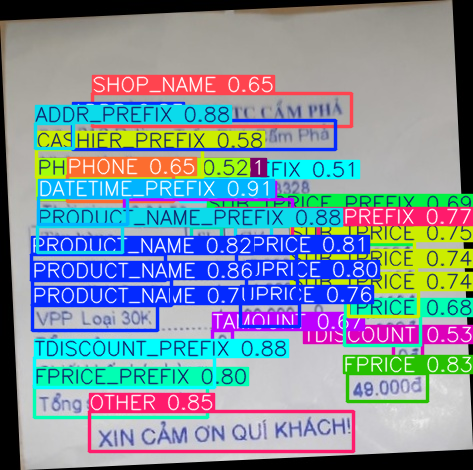


 Kết quả detect:
  DATETIME_PREFIX          : 90.7% | bbox: [38, 197, 127, 224]
  TDISCOUNT_PREFIX         : 88.1% | bbox: [34, 357, 214, 387]
  ADDR_PREFIX              : 87.8% | bbox: [35, 123, 73, 148]
  PRODUCT_NAME_PREFIX      : 87.8% | bbox: [37, 226, 122, 252]
  PRODUCT_NAME             : 86.0% | bbox: [32, 279, 171, 305]
  OTHER                    : 84.8% | bbox: [89, 411, 353, 451]
  FPRICE                   : 82.7% | bbox: [347, 373, 427, 401]
  ADDR                     : 82.7% | bbox: [72, 120, 335, 149]
  PRODUCT_NAME             : 81.8% | bbox: [31, 254, 165, 280]
  UPRICE                   : 80.9% | bbox: [236, 253, 296, 277]
  FPRICE_PREFIX            : 80.3% | bbox: [34, 385, 207, 417]
  DATETIME                 : 79.8% | bbox: [124, 199, 292, 224]
  UPRICE                   : 79.6% | bbox: [246, 278, 297, 301]
  UDISCOUNT_PREFIX         : 77.1% | bbox: [292, 225, 318, 248]
  UPRICE                   : 76.2% | bbox: [240, 303, 299, 326]
  SUB_TPRICE               : 74.

In [10]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load best model
best_model = YOLO('/content/drive/MyDrive/ImportWeb/detect_bill/weights/best.pt')

# Upload ảnh test
from google.colab import files
uploaded = files.upload()
test_img = list(uploaded.keys())[0]

# Predict
results = best_model(test_img, conf=0.5)

# Hiển thị kết quả
annotated = results[0].plot()
cv2_imshow(annotated)

print("\n Kết quả detect:")
for box in results[0].boxes:
    class_name = results[0].names[int(box.cls)]
    confidence = float(box.conf)
    coords     = box.xyxy[0].tolist()
    print(f"  {class_name:25s}: {confidence:.1%} | bbox: {[int(c) for c in coords]}")

In [13]:
import shutil
import os

os.makedirs('/content/drive/MyDrive/ImportWeb/models', exist_ok=True)

shutil.copy(
    '/content/drive/MyDrive/ImportWeb/detect_bill/weights/best.pt',
    '/content/drive/MyDrive/ImportWeb/models/best.pt'
)

print("Đã lưu model vào Drive!")

Đã lưu model vào Drive!
